In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import json
import os

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adagrad


In [2]:
LOG_DIR = "../logs"
os.makedirs(LOG_DIR, exist_ok=True)

In [3]:
def train_optimizer(optimizer, name):

    print(f"\nTraining with {name}\n")

    base_model = tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(224,224,3)
    )

    base_model.trainable = False

    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)

    outputs = tf.keras.layers.Dense(4, activation="sigmoid")(x)

    model = tf.keras.Model(
        inputs=base_model.input,
        outputs=outputs
    )

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"]
    )

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=3
    )

    # Save model
    model.save(f"../models/resnet50_{name}.h5")

    # Save history
    with open(f"../logs/{name}_history.json", "w") as f:
        json.dump(history.history, f)

    return history

In [4]:
import sys
sys.path.append("../training")

from data_generator import DataGenerator

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

DATA_DIR = "../data"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
CSV_PATH = os.path.join(DATA_DIR, "train_solution_bounding_boxes.csv")

df = pd.read_csv(CSV_PATH)
df["image_path"] = df["image"].apply(lambda x: os.path.join(TRAIN_DIR, x))

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)

In [6]:
BATCH_SIZE = 16

train_generator = DataGenerator(train_df, BATCH_SIZE, augment=True)
val_generator = DataGenerator(val_df, BATCH_SIZE, augment=False)

In [7]:
def create_model():
    
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )
    
    base_model.trainable = False
    
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.3)(x)
    
    output = Dense(4, activation='sigmoid')(x)
    
    model = Model(inputs=base_model.input, outputs=output)
    
    return model

In [8]:
LOG_DIR = "../logs"
os.makedirs(LOG_DIR, exist_ok=True)

In [9]:
def train_optimizer(optimizer, name):
    
    model = create_model()
    
    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )
    
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=5
    )
    
    model.save(f"../models/resnet50_{name}.h5")
    
    with open(f"../logs/{name}_history.json", "w") as f:
        json.dump(history.history, f)
    
    return history

In [10]:
history_adam = train_optimizer(
    Adam(learning_rate=0.0001),
    "adam"
)

c:\Users\Admin\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 36s 922ms/step - loss: 0.0735 - mae: 0.2156 - val_loss: 0.0456 - val_mae: 0.1430
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 21s 788ms/step - loss: 0.0642 - mae: 0.1949 - val_loss: 0.0433 - val_mae: 0.1403
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 21s 789ms/step - loss: 0.0644 - mae: 0.1935 - val_loss: 0.0434 - val_mae: 0.1402
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 798ms/step - loss: 0.0620 - mae: 0.1883 - val_loss: 0.0433 - val_mae: 0.1388
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 21s 782ms/step - loss: 0.0599 - mae: 0.1817 - val_loss: 0.0439 - val_mae: 0.1388


In [11]:
history_sgd = train_optimizer(
    SGD(learning_rate=0.001),
    "sgd"
)

Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - loss: 0.0751 - mae: 0.2008 - val_loss: 0.0561 - val_mae: 0.1558
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - loss: 0.0724 - mae: 0.2019 - val_loss: 0.0484 - val_mae: 0.1450
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - loss: 0.0664 - mae: 0.1961 - val_loss: 0.0451 - val_mae: 0.1404
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - loss: 0.0627 - mae: 0.1922 - val_loss: 0.0439 - val_mae: 0.1388
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 803ms/step - loss: 0.0642 - mae: 0.1934 - val_loss: 0.0440 - val_mae: 0.1392


In [12]:
history_rms = train_optimizer(
    RMSprop(learning_rate=0.0001),
    "rmsprop"
)

Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 35s 959ms/step - loss: 0.0668 - mae: 0.1979 - val_loss: 0.0431 - val_mae: 0.1414
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 820ms/step - loss: 0.0627 - mae: 0.1903 - val_loss: 0.0447 - val_mae: 0.1436
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 41s 820ms/step - loss: 0.0628 - mae: 0.1886 - val_loss: 0.0461 - val_mae: 0.1415
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 23s 827ms/step - loss: 0.0590 - mae: 0.1827 - val_loss: 0.0438 - val_mae: 0.1404
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 23s 843ms/step - loss: 0.0585 - mae: 0.1793 - val_loss: 0.0428 - val_mae: 0.1376


In [13]:
history_ada = train_optimizer(
    Adagrad(learning_rate=0.01),
    "adagrad"
)

Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - loss: 0.0725 - mae: 0.2053 - val_loss: 0.0436 - val_mae: 0.1405
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 23s 832ms/step - loss: 0.0636 - mae: 0.1920 - val_loss: 0.0440 - val_mae: 0.1464
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 23s 844ms/step - loss: 0.0621 - mae: 0.1869 - val_loss: 0.0497 - val_mae: 0.1462
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 23s 842ms/step - loss: 0.0598 - mae: 0.1806 - val_loss: 0.0430 - val_mae: 0.1382
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 23s 834ms/step - loss: 0.0549 - mae: 0.1728 - val_loss: 0.0438 - val_mae: 0.1409


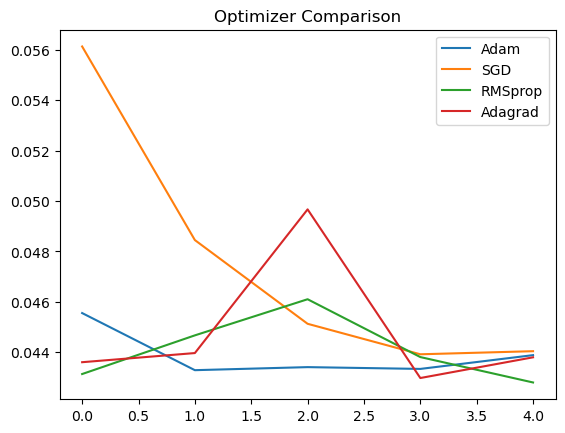

In [14]:
plt.figure()

plt.plot(history_adam.history['val_loss'], label='Adam')
plt.plot(history_sgd.history['val_loss'], label='SGD')
plt.plot(history_rms.history['val_loss'], label='RMSprop')
plt.plot(history_ada.history['val_loss'], label='Adagrad')

plt.legend()
plt.title("Optimizer Comparison")
plt.savefig("../evaluation/optimizer_comparison.png")
plt.show()

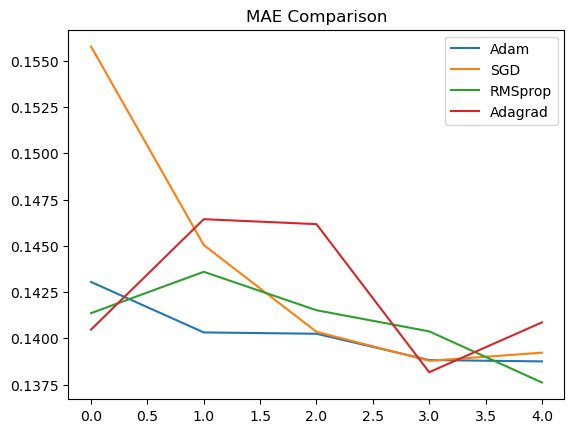

In [15]:
plt.figure()

plt.plot(history_adam.history['val_mae'], label='Adam')
plt.plot(history_sgd.history['val_mae'], label='SGD')
plt.plot(history_rms.history['val_mae'], label='RMSprop')
plt.plot(history_ada.history['val_mae'], label='Adagrad')

plt.legend()
plt.title("MAE Comparison")
plt.savefig("../evaluation/mae_comparison.png")
plt.show()

In [16]:
results = {
    "Adam": min(history_adam.history['val_loss']),
    "SGD": min(history_sgd.history['val_loss']),
    "RMSprop": min(history_rms.history['val_loss']),
    "Adagrad": min(history_ada.history['val_loss'])
}

results

{'Adam': 0.043286778032779694,
 'SGD': 0.04391709342598915,
 'RMSprop': 0.042798805981874466,
 'Adagrad': 0.04297535493969917}

In [17]:
history_adam = train_optimizer(
    Adam(learning_rate=0.0001),
    "adam"
)

Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 34s 947ms/step - loss: 0.0692 - mae: 0.2052 - val_loss: 0.0453 - val_mae: 0.1421
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 804ms/step - loss: 0.0662 - mae: 0.1956 - val_loss: 0.0440 - val_mae: 0.1411
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 23s 842ms/step - loss: 0.0609 - mae: 0.1873 - val_loss: 0.0449 - val_mae: 0.1416
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 26s 974ms/step - loss: 0.0602 - mae: 0.1862 - val_loss: 0.0436 - val_mae: 0.1400
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 23s 843ms/step - loss: 0.0596 - mae: 0.1824 - val_loss: 0.0431 - val_mae: 0.1388


In [18]:
history_sgd = train_optimizer(
    SGD(learning_rate=0.001),
    "sgd"
)

Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 33s 962ms/step - loss: 0.0806 - mae: 0.2262 - val_loss: 0.0512 - val_mae: 0.1730
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - loss: 0.0691 - mae: 0.2027 - val_loss: 0.0444 - val_mae: 0.1484
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - loss: 0.0646 - mae: 0.1947 - val_loss: 0.0433 - val_mae: 0.1400
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - loss: 0.0625 - mae: 0.1928 - val_loss: 0.0433 - val_mae: 0.1380
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - loss: 0.0636 - mae: 0.1929 - val_loss: 0.0435 - val_mae: 0.1382


In [19]:
history_rms = train_optimizer(
    RMSprop(learning_rate=0.001),
    "rmsprop"
)

Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 37s 989ms/step - loss: 0.0914 - mae: 0.2288 - val_loss: 0.0661 - val_mae: 0.2098
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - loss: 0.0606 - mae: 0.1811 - val_loss: 0.0447 - val_mae: 0.1522
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - loss: 0.0564 - mae: 0.1666 - val_loss: 0.0433 - val_mae: 0.1397
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - loss: 0.0531 - mae: 0.1589 - val_loss: 0.0457 - val_mae: 0.1422
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - loss: 0.0524 - mae: 0.1580 - val_loss: 0.0441 - val_mae: 0.1391


In [20]:
history_ada = train_optimizer(
    Adagrad(learning_rate=0.01),   
    "adagrad"
)

Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - loss: 0.0690 - mae: 0.2019 - val_loss: 0.0447 - val_mae: 0.1468
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 23s 840ms/step - loss: 0.0612 - mae: 0.1861 - val_loss: 0.0432 - val_mae: 0.1398
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 26s 977ms/step - loss: 0.0591 - mae: 0.1813 - val_loss: 0.0433 - val_mae: 0.1397
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - loss: 0.0591 - mae: 0.1792 - val_loss: 0.0439 - val_mae: 0.1400
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - loss: 0.0565 - mae: 0.1728 - val_loss: 0.0443 - val_mae: 0.1393
